In [ ]:
from google.colab import files
uploaded = files.upload()

# World Happiness Data Analysis

## Project Overview
This project explores the **World Happiness dataset** to understand the factors that influence happiness across different countries.

Using Python and data analysis techniques, we will:

- Explore the structure of the dataset
- Identify missing values
- Clean the data
- Perform exploratory data analysis (EDA)
- Visualize relationships between variables
- Extract meaningful insights

The goal of this analysis is to understand which factors most strongly influence happiness levels around the world.

## Dataset Description

The dataset contains country-level indicators related to happiness and quality of life.

### Key Features

- **Country name** – Name of the country
- **year** – Year of observation
- **Life Ladder** – Happiness score
- **Log GDP per capita** – Economic prosperity
- **Social support** – Perceived social support
- **Healthy life expectancy at birth** – Health indicator
- **Freedom to make life choices** – Personal freedom
- **Generosity** – Measure of generosity
- **Perceptions of corruption** – Public perception of corruption

These variables help explain differences in happiness levels between countries.

In [47]:
# Import important libraries for our data analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("World Happiness Report 2005-2021.csv")
df.head()

,Country_name,Life Ladder,Log GDP per capita,Social_support,Healthy life expectancy at birth,Freedom_to_make_life_choices,Generosity,Perceptions_of_corruption,Positive affect,Negative affect,Confidence in national government
0,Afghanistan,3.723590,7.302574,0.450662,50.500000,0.718114,0.173169,0.881686,0.414297,0.258195,0.612072
1,Afghanistan,4.401778,7.472446,0.552308,50.799999,0.678896,0.195469,0.850035,0.481421,0.237092,0.611545
2,Afghanistan,4.758381,7.579183,0.539075,51.099998,0.600127,0.125859,0.706766,0.516907,0.275324,0.299357
3,Afghanistan,3.831719,7.552006,0.521104,51.400002,0.495901,0.167723,0.731109,0.479835,0.267175,0.307386
4,Albania,4.639548,9.454930,0.637698,69.050003,0.749611,-0.028629,0.876135,0.547240,0.333884,0.457738



## Understanding the Dataset

Before performing analysis, we first explore the structure of the dataset.

We will check:

- Number of rows and columns
- Column names
- Data types
- Missing values

In [48]:
# Inorder to knoow the number of rows and columns in our dataset
df.shape

(78, 11)

In [49]:
# Show column names
df.columns

Index(['Country_name', 'Life Ladder', 'Log GDP per capita', 'Social_support',
       'Healthy life expectancy at birth', 'Freedom_to_make_life_choices',
       'Generosity', 'Perceptions_of_corruption', 'Positive affect',
       'Negative affect', 'Confidence in national government'],
      dtype='object')

In [50]:
# Show information about dataset structure , datatype of each columns ....
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 11 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Country_name                       78 non-null     object 
 1   Life Ladder                        78 non-null     float64
 2   Log GDP per capita                 78 non-null     float64
 3   Social_support                     77 non-null     float64
 4   Healthy life expectancy at birth   78 non-null     float64
 5   Freedom_to_make_life_choices       78 non-null     float64
 6   Generosity                         75 non-null     float64
 7   Perceptions_of_corruption          78 non-null     float64
 8   Positive affect                    77 non-null     float64
 9   Negative affect                    77 non-null     float64
 10  Confidence in national government  67 non-null     float64
dtypes: float64(10), object(1)
memory usage: 6.8+ KB


 **Check for Missing Data**

In [51]:
# let us Count missing values in each column as we see the column of confidence in national government has many nulls so we need to handle those missing values well.
df.isnull().sum()

,0
Country_name,0
Life Ladder,0
Log GDP per capita,0
Social_support,1
Healthy life expectancy at birth,0
Freedom_to_make_life_choices,0
Generosity,3
Perceptions_of_corruption,0
Positive affect,1
Negative affect,1


In [52]:
# Total missing values in the whole dataset
df.isnull().sum().sum()

np.int64(17)

In [53]:
(df.isnull().sum() / len(df)) * 100

,0
Country_name,0.000000
Life Ladder,0.000000
Log GDP per capita,0.000000
Social_support,1.282051
Healthy life expectancy at birth,0.000000
Freedom_to_make_life_choices,0.000000
Generosity,3.846154
Perceptions_of_corruption,0.000000
Positive affect,1.282051
Negative affect,1.282051


**Since our total missing values in our data set is only 17 , we can easily remove them or replace them with their column average value . For my case replacing with the column average is better option , rather than loosing our row datas .**

In [54]:
df.fillna(df.mean(numeric_only=True), inplace=True)
# Now we have replaced all our missing datas with the column average.

In [56]:
# lets check if we have really replaced all missing datas
df.isnull().sum().sum()

np.int64(0)

In [57]:
# We need to import sqlite3 to create and interact with a SQL database
import sqlite3
# Import matplotlib for visualization
import matplotlib.pyplot as plt

In [58]:
# Create a connection to a SQLite database
conn = sqlite3.connect("happiness.db")

# Store the dataframe inside the database as a table
df.to_sql("happiness", conn, if_exists="replace", index=False)

78

**Top 10 Happiest Countries**

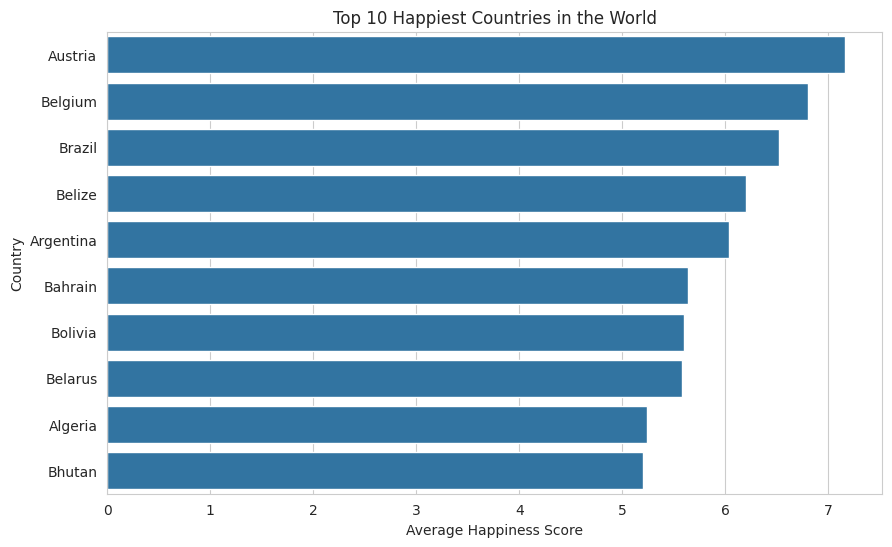

In [59]:
# Calculate average happiness score by country

top_countries = (
    df.groupby("Country_name")["Life Ladder"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Happiest Countries in the World")
plt.xlabel("Average Happiness Score")
plt.ylabel("Country")

plt.show()

In [83]:
pd.read_sql("""
SELECT Country_name, AVG("Life Ladder") AS avg_happiness
FROM happiness
GROUP BY Country_name
ORDER BY avg_happiness DESC
LIMIT 10;
""", conn)

,Country_name,avg_happiness
0,Austria,7.162830
1,Belgium,6.805449
2,Brazil,6.515243
3,Belize,6.203146
4,Argentina,6.031193
5,Bahrain,5.635653
6,Bolivia,5.596464
7,Belarus,5.576553
8,Algeria,5.236032
9,Bhutan,5.196599


**Top 10 countries With Highest GDP**

In [82]:
pd.read_sql("""
SELECT Country_name, AVG("Log GDP per capita") AS "Avg Log GDP per capita"
FROM happiness
GROUP BY Country_name
ORDER BY "Avg Log GDP per capita" DESC
LIMIT 10
""", conn)

,Country_name,Avg Log GDP per capita
0,Austria,10.892814
1,Belgium,10.825886
2,Bahrain,10.716341
3,Argentina,9.970117
4,Bulgaria,9.795598
5,Belarus,9.720130
6,Botswana,9.556903
7,Brazil,9.543568
8,Albania,9.504680
9,Azerbaijan,9.443730


**Top 10 Countries With Lowest Happiness**

In [81]:
pd.read_sql("""
SELECT Country_name, Avg("Life Ladder") As Avg_life_ladder
FROM happiness
Group BY Country_name
ORDER BY Avg_life_ladder ASC
LIMIT 10
""", conn)

,Country_name,Avg_life_ladder
0,Benin,3.622407
1,Burkina Faso,3.801491
2,Bulgaria,3.877152
3,Botswana,3.998793
4,Afghanistan,4.178867
5,Angola,4.420299
6,Armenia,4.585413
7,Bangladesh,4.659503
8,Bosnia and Herzegovina,4.931642
9,Azerbaijan,4.934481


**Top 10 Countries With Highest Freedom**

In [80]:
pd.read_sql("""
SELECT Country_name, Avg(Freedom_to_make_life_choices) As AVG_Freedom
FROM happiness
GROUP BY Country_name
ORDER BY AVG_Freedom DESC
LIMIT 10
""", conn)

,Country_name,AVG_Freedom
0,Austria,0.870061
1,Botswana,0.832263
2,Bhutan,0.824842
3,Bahrain,0.823767
4,Brazil,0.798739
5,Belize,0.789438
6,Albania,0.786460
7,Belgium,0.771561
8,Bolivia,0.763657
9,Argentina,0.741386


**Top 10 Countries With Highest Social Support**

In [79]:
pd.read_sql("""
SELECT Country_name, AVG(Social_support) AS Avg_Social_Support
FROM happiness
Group by Country_name
ORDER BY Avg_Social_Support DESC
LIMIT 10
""", conn)

,Country_name,Avg_Social_Support
0,Austria,0.917432
1,Belarus,0.899398
2,Bahrain,0.896851
3,Argentina,0.894454
4,Belgium,0.893895
5,Brazil,0.872991
6,Bhutan,0.848955
7,Bulgaria,0.845017
8,Botswana,0.832806
9,Algeria,0.821756


**Top 10 Countries With Highest Life Expectancy**

In [78]:
pd.read_sql("""
SELECT Country_name, Avg("Healthy life expectancy at birth") AS AVG_life_expectancy
FROM happiness
GROUP BY Country_name
ORDER BY AVG_life_expectancy DESC
LIMIT 10
""", conn)

,Country_name,AVG_life_expectancy
0,Austria,71.025002
1,Belgium,70.674999
2,Albania,69.100000
3,Bosnia and Herzegovina,67.000000
4,Argentina,66.434000
5,Algeria,66.120000
6,Bahrain,65.240001
7,Bulgaria,65.106664
8,Belize,64.650002
9,Brazil,64.152143


**Top 10 Countries With Highest Corruption Perception:**

In [77]:
pd.read_sql("""
SELECT Country_name, AVG(Perceptions_of_corruption) AS "Avg perceptyion of corruption"
FROM happiness
Group BY Country_name
ORDER BY "Avg perceptyion of corruption" DESC
LIMIT 10
""", conn)

,Country_name,Avg perceptyion of corruption
0,Bulgaria,0.955003
1,Bosnia and Herzegovina,0.942432
2,Albania,0.895407
3,Angola,0.867018
4,Argentina,0.845978
5,Armenia,0.833479
6,Benin,0.821527
7,Botswana,0.807112
8,Bangladesh,0.797951
9,Burkina Faso,0.797701


**Average Happiness Score**

In [67]:
pd.read_sql("""
SELECT AVG("Life Ladder") AS average_happiness
FROM happiness
""", conn)

,average_happiness
0,5.231492


**Top 10 Countries With Highest Positive Emotions**

In [76]:
pd.read_sql("""
SELECT Country_name, AVG("Positive affect") AS "Avg Positive affect"
FROM happiness
GROUP BY Country_name
ORDER BY "Avg Positive affect" DESC
LIMIT 10
""", conn)

,Country_name,Avg Positive affect
0,Belize,0.733284
1,Bolivia,0.729851
2,Austria,0.721853
3,Brazil,0.721028
4,Bhutan,0.720516
5,Argentina,0.716457
6,Burkina Faso,0.677514
7,Belgium,0.659084
8,Botswana,0.651457
9,Angola,0.625734


**Top 10 Countries With Highest Negative Emotions**

In [75]:
pd.read_sql("""
SELECT Country_name, AVG("Negative affect") "Avg Negative affect"
FROM happiness
GROUP BY Country_name
ORDER BY "Avg Negative affect" DESC
LIMIT 10
""", conn)

,Country_name,Avg Negative affect
0,Armenia,0.440568
1,Bahrain,0.409061
2,Bolivia,0.396045
3,Angola,0.351173
4,Bosnia and Herzegovina,0.343335
5,Argentina,0.322618
6,Brazil,0.312399
7,Albania,0.289086
8,Bangladesh,0.288597
9,Bhutan,0.284346


**Correlational Analysis Of Happiness Score(Life Ladder)**

In this section, we analyze how different variables relate to the happiness score (Life Ladder).
Correlation helps us understand which factors are most strongly associated with happiness.

**The dataset includes several potential factors such as:**

Economic prosperity (Log GDP per capita)




*  Social relationships (Social_support)
*  Health (Healthy life expectancy at birth)
* Personal freedom (Freedom_to_make_life_choices)
* Emotional well-being (Positive affect / Negative affect)
* Trust in government (Confidence in national government)
* Corruption perception (Perceptions_of_corruption)















In [84]:
# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# View the numeric columns
numeric_df.head()

,Life Ladder,Log GDP per capita,Social_support,Healthy life expectancy at birth,Freedom_to_make_life_choices,Generosity,Perceptions_of_corruption,Positive affect,Negative affect,Confidence in national government
0,3.723590,7.302574,0.450662,50.500000,0.718114,0.173169,0.881686,0.414297,0.258195,0.612072
1,4.401778,7.472446,0.552308,50.799999,0.678896,0.195469,0.850035,0.481421,0.237092,0.611545
2,4.758381,7.579183,0.539075,51.099998,0.600127,0.125859,0.706766,0.516907,0.275324,0.299357
3,3.831719,7.552006,0.521104,51.400002,0.495901,0.167723,0.731109,0.479835,0.267175,0.307386
4,4.639548,9.454930,0.637698,69.050003,0.749611,-0.028629,0.876135,0.547240,0.333884,0.457738


In [85]:
# Calculate correlations between all numeric variables
correlation_matrix = numeric_df.corr()

# Display the correlation matrix
correlation_matrix

,Life Ladder,Log GDP per capita,Social_support,Healthy life expectancy at birth,Freedom_to_make_life_choices,Generosity,Perceptions_of_corruption,Positive affect,Negative affect,Confidence in national government
Life Ladder,1.000000,0.569674,0.591126,0.634834,0.443777,0.084525,-0.482069,0.590075,0.019902,-0.195540
Log GDP per capita,0.569674,1.000000,0.777074,0.692038,0.362794,-0.292523,-0.444803,0.311706,0.027895,-0.103626
Social_support,0.591126,0.777074,1.000000,0.514936,0.320169,-0.270829,-0.418157,0.452058,-0.001506,-0.096553
Healthy life expectancy at birth,0.634834,0.692038,0.514936,1.000000,0.211241,-0.075185,-0.282101,0.142414,0.082091,-0.237133
Freedom_to_make_life_choices,0.443777,0.362794,0.320169,0.211241,1.000000,0.139823,-0.389938,0.503109,-0.072572,0.227389
Generosity,0.084525,-0.292523,-0.270829,-0.075185,0.139823,1.000000,-0.042316,0.235221,0.110687,0.118432
Perceptions_of_corruption,-0.482069,-0.444803,-0.418157,-0.282101,-0.389938,-0.042316,1.000000,-0.206362,0.124351,-0.269234
Positive affect,0.590075,0.311706,0.452058,0.142414,0.503109,0.235221,-0.206362,1.000000,0.111463,-0.036818
Negative affect,0.019902,0.027895,-0.001506,0.082091,-0.072572,0.110687,0.124351,0.111463,1.000000,-0.308790
Confidence in national government,-0.195540,-0.103626,-0.096553,-0.237133,0.227389,0.118432,-0.269234,-0.036818,-0.308790,1.000000


In [86]:
# Sort correlations with happiness
correlation_matrix["Life Ladder"].sort_values(ascending=False)

,Life Ladder
Life Ladder,1.000000
Healthy life expectancy at birth,0.634834
Social_support,0.591126
Positive affect,0.590075
Log GDP per capita,0.569674
Freedom_to_make_life_choices,0.443777
Generosity,0.084525
Negative affect,0.019902
Confidence in national government,-0.195540
Perceptions_of_corruption,-0.482069


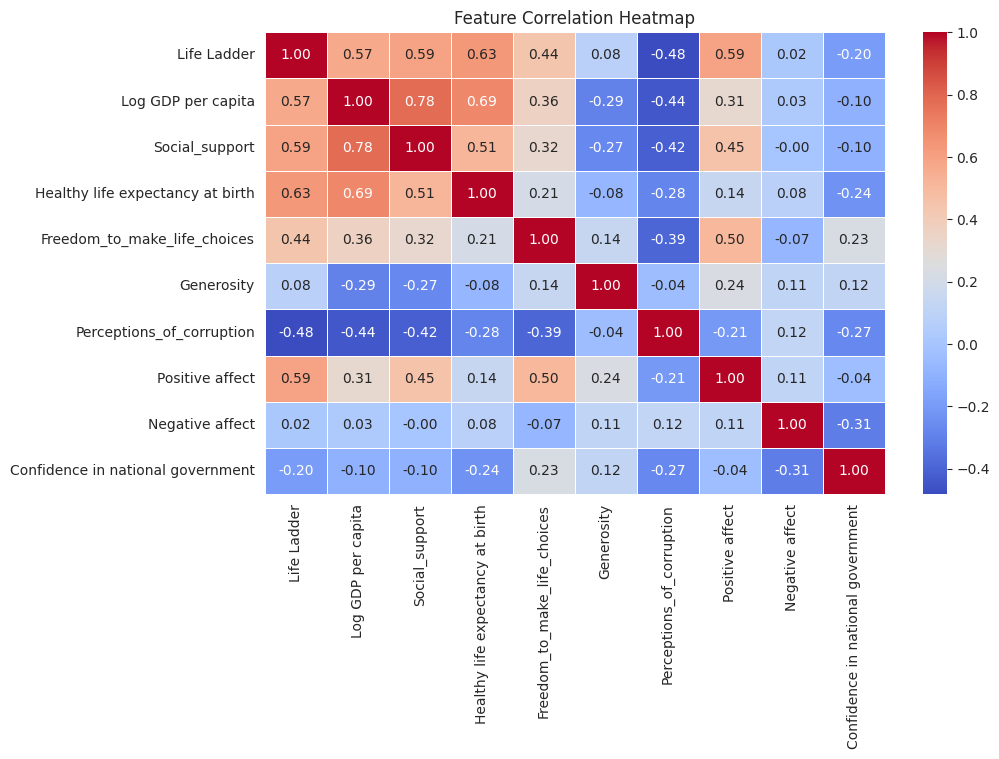

In [87]:

sns.set_style("whitegrid")
plt.figure(figsize=(10,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

**Strong Positive Relationships**

   * Healthy life expectancy
   * Positive emotions
   * Social support

**Insight**: positive feelings, healthier countries with strong social support tend to be happier.


  

**Moderate Relationships**

   * Freedom to make life choices
   * Log GDP per capital

**Insight**: Personal freedom and Log GDP per capital also contribute to happiness.



**Negative Relationships**

   * Negative affect
   * Perceptions of corruption

**Insight**: Countries with more negative emotions and corruption tend to have lower happiness levels.